# SBER: результаты трёх заданий

**Brent:** расширенное сравнение 31 спецификации, хронологическая оценка и квантильная сеть по мотивам ВКР. Срез — март 2026.

**Бот:** дружелюбный тон, ответы со ссылками и проверками. Живой API в этой доработке не вызывался.

**Excel:** фактические объёмы за сентябрь 2026, прозрачный учёт отсутствующих цен Востока.

Run All читает сохранённые результаты, не запускает обучение, Telegram или платные API. Все команды выполняются из корня `sber-analyst-test`.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
from openpyxl import load_workbook
ROOT = Path.cwd()
assert (ROOT / "task1_brent").is_dir(), "Запустите notebook из корня репозитория"
pd.set_option("display.max_columns", 15)
B = ROOT / "task1_brent" / "outputs"


# **Задание 1**

На основе открытых источников данных реализуйте прогноз цен на нефть Brent до конца 2027 года

*Ознакомьтесь с лучшими подходами и практиками, используйте различные методы прогнозирования, не ограничиваясь авторегрессией*

## Данные и честная временная проверка

467 месячных наблюдений Brent: май 1987 — март 2026. Исходный CSV не изменён.
Месячные цены считаются доступными в origin; точный день публикации не моделируется.
Train / validation / test делятся по календарю, без перемешивания. Все цели обучающего
окна должны быть известны к моменту выпуска. Для multi-output нейросети проверяется
последняя из 21 цели. Масштабирование обучается внутри доступного окна.

Внутренняя validation с purge используется для early stopping, внешняя validation —
для выбора модели по MAE. Выбор зафиксирован **до** расчёта test. В expanding-проверке
разрешено использовать уже известные прошлые факты. Финальный refit на всей истории
делается после оценки, для будущего прогноза.

История test уже обсуждалась в предыдущих ревью: это ретроспективная оценка,
не новый нетронутый holdout. Перекрывающиеся горизонты зависимы; значимость победы не заявляется.

In [2]:
E = ROOT / "task1_brent/outputs/extended_full"
display(pd.read_csv(E / "split.csv"))
meta = json.loads((E / "metadata.json").read_text())
display(pd.DataFrame([{"Режим":meta["mode"],"Шаг origin, мес.":meta["stride_months"],"Максимум эпох":meta["epochs_max"],"Время, сек.":meta["elapsed_seconds"]}]))

display(pd.read_csv(E / "input_inventory.csv")[["file","first","last","frequency","extra_rows_in_month","missing_months"]].fillna("—"))


,period,start,end,n
0,train,1987-05-01,2014-06-01,326
1,validation,2014-07-01,2020-04-01,70
2,test,2020-05-01,2026-03-01,71


,Режим,"Шаг origin, мес.",Максимум эпох,"Время, сек."
0,full,3,160,298.3


,file,first,last,frequency,extra_rows_in_month,missing_months
0,euro_area_cpi.xlsx,2010-01-31,2026-03-31,monthly,0.0,—
1,ruonia.xlsx,2010-01-11,2026-04-16,daily_business,—,—
2,russia_cpi.xlsx,2010-01-01,2026-02-01,monthly,0.0,—
3,russia_cpi_key_rate.xlsx,2010-01-31,2026-02-01,monthly,0.0,—
4,russia_industry_yoy.xlsx,2010-01-31,2026-02-28,monthly,0.0,—
5,russia_m2.xlsx,2010-01-31,2026-03-31,monthly,0.0,—
6,russia_private_credit.xlsx,2010-01-29,2026-02-28,monthly,14.0,—
7,russia_public_debt.xlsx,2010-01-31,2026-03-31,monthly,0.0,—
8,russia_retail_mom.xlsx,2010-01-31,2026-02-28,monthly,0.0,—
9,russia_retail_yoy.xlsx,2010-01-31,2026-02-28,monthly,0.0,—


На каждом периоде — 17 одинаковых дат выпуска для всех моделей и горизонтов 1–21.
Последние 20 месяцев периода используются только как цели.

Первый validation-прогноз: окно июль 2013 — июнь 2014, цели июль 2014 — март 2016.
Первый test-прогноз: окно май 2019 — апрель 2020, цели май 2020 — январь 2022.

## Группы моделей

| Группа | Спецификации |
|---|---|
| Baseline | naive, drift, 9 вариантов возврата к среднему |
| Эконометрика | AR(1/3/6/12), 3 ARIMA, ETS |
| ML | прежние прямые Ridge и HGB, ансамбль и 4 исключения участников |
| Нейросети | RNN, LSTM, CNN; по 3 seed |
| Вероятностный прогноз | QRNN по 5 seed, исторические квантили доходности как ориентир |

Нейросети компактные: окно 12, скрытый размер 8. До 160 эпох с ранней остановкой.
В QRNN 19 квантилей, изотоническая коррекция пересечений. От ВКР взяты архитектурная
идея и метрики; признаки, многогоризонтные головы и обучение адаптированы к Brent.
Точное сопоставление — `task1_brent/EXTENDED_METHOD.md`.

## Результаты: validation и test

Таблица содержит все варианты, включая неудачные. Меньшая MAE лучше.

In [3]:
metrics = pd.read_csv(E / "metrics.csv")
key_horizons = [1,3,6,12,21]
for phase in ["validation","test"]:
    display(Markdown(f"**{phase}: MAE, USD/барр.**"))
    display(metrics[(metrics.period==phase)&metrics.horizon.isin(key_horizons)].pivot(index="model",columns="horizon",values="MAE").round(2))


**validation: MAE, USD/барр.**

horizon,1,3,6,12,21
model,,,,,
ar_1,4.17,8.87,14.71,20.40,26.45
ar_12,4.29,8.51,15.38,22.25,33.94
ar_3,3.83,8.59,15.74,24.11,34.05
ar_6,3.94,8.42,15.83,22.47,29.87
arima_011,3.91,8.49,14.48,17.78,21.65
arima_110,3.78,8.27,14.53,17.67,21.46
arima_111,3.85,8.43,14.52,17.73,21.58
cnn,4.04,8.06,13.88,17.96,22.74
drift,4.24,8.46,14.31,17.67,21.13


**test: MAE, USD/барр.**

horizon,1,3,6,12,21
model,,,,,
ar_1,5.88,9.52,12.94,21.14,29.48
ar_12,6.92,11.06,13.19,22.14,30.78
ar_3,6.14,9.56,12.30,21.02,29.79
ar_6,6.53,10.10,12.82,21.38,29.82
arima_011,6.16,9.80,12.93,21.08,27.89
arima_110,6.10,9.93,12.98,21.03,28.03
arima_111,6.26,10.02,13.17,21.25,27.87
cnn,5.76,10.09,11.98,18.04,19.81
drift,5.92,10.01,13.73,20.84,25.52


# Расширенный эксперимент Brent

Режим: full. Затрачено 298.3 с на этой среде; это не замер Mac.

Выбор модели сделан по MAE validation до расчёта test. Период test уже обсуждался в предыдущих ревью: оценка ретроспективная, не новый независимый тест.

| Горизонт | Выбрана на validation | MAE validation | MAE test | MAE naive test |
|---|---|---:|---:|---:|
| 1 | hgb_direct | 3.28 | 6.23 | 5.91 |
| 3 | mr_180_6 | 7.06 | 8.84 | 10.08 |
| 6 | mr_180_6 | 8.90 | 10.45 | 13.68 |
| 12 | mr_180_6 | 9.05 | 13.76 | 20.51 |
| 21 | mr_180_6 | 9.60 | 14.13 | 24.22 |

Прогноз к декабрю 2027: **75.08 USD/барр.**, модель `mr_180_6`. Это результат модели от мартовского среза, а не актуальный прогноз от октября.

Модели разных горизонтов выбираются отдельно, поэтому итоговая линия может иметь изломы. Экономические драйверы не оценивались причинно.

Пересекающиеся горизонты зависимы: строки нельзя трактовать как независимые повторения. Статистическая значимость победы не заявляется. Сравнение всех моделей выполняется на одинаковых датах внутри каждого периода; последние месяцы используются только как цели, чтобы все 21 горизонт были наблюдаемы.

QRNN на h=21: измеренное покрытие 76.5%, средняя ширина 62.90 USD/барр.; номинал 90%. Интервал в декабре 2027: 75.51–153.92. Это интервал QRNN, а не выбранной точечной модели.
Полная сетка и метрики есть в CSV. `crps_central_approx` — интеграл pinball только по [0.05,0.95], без хвостов; это не точный полный CRPS. Калибровка интервалов на test не выполнялась.

Сопоставление с дипломом и схема обучения: ../../EXTENDED_METHOD.md. Ошибки оптимизации/сходимости: warnings.json.


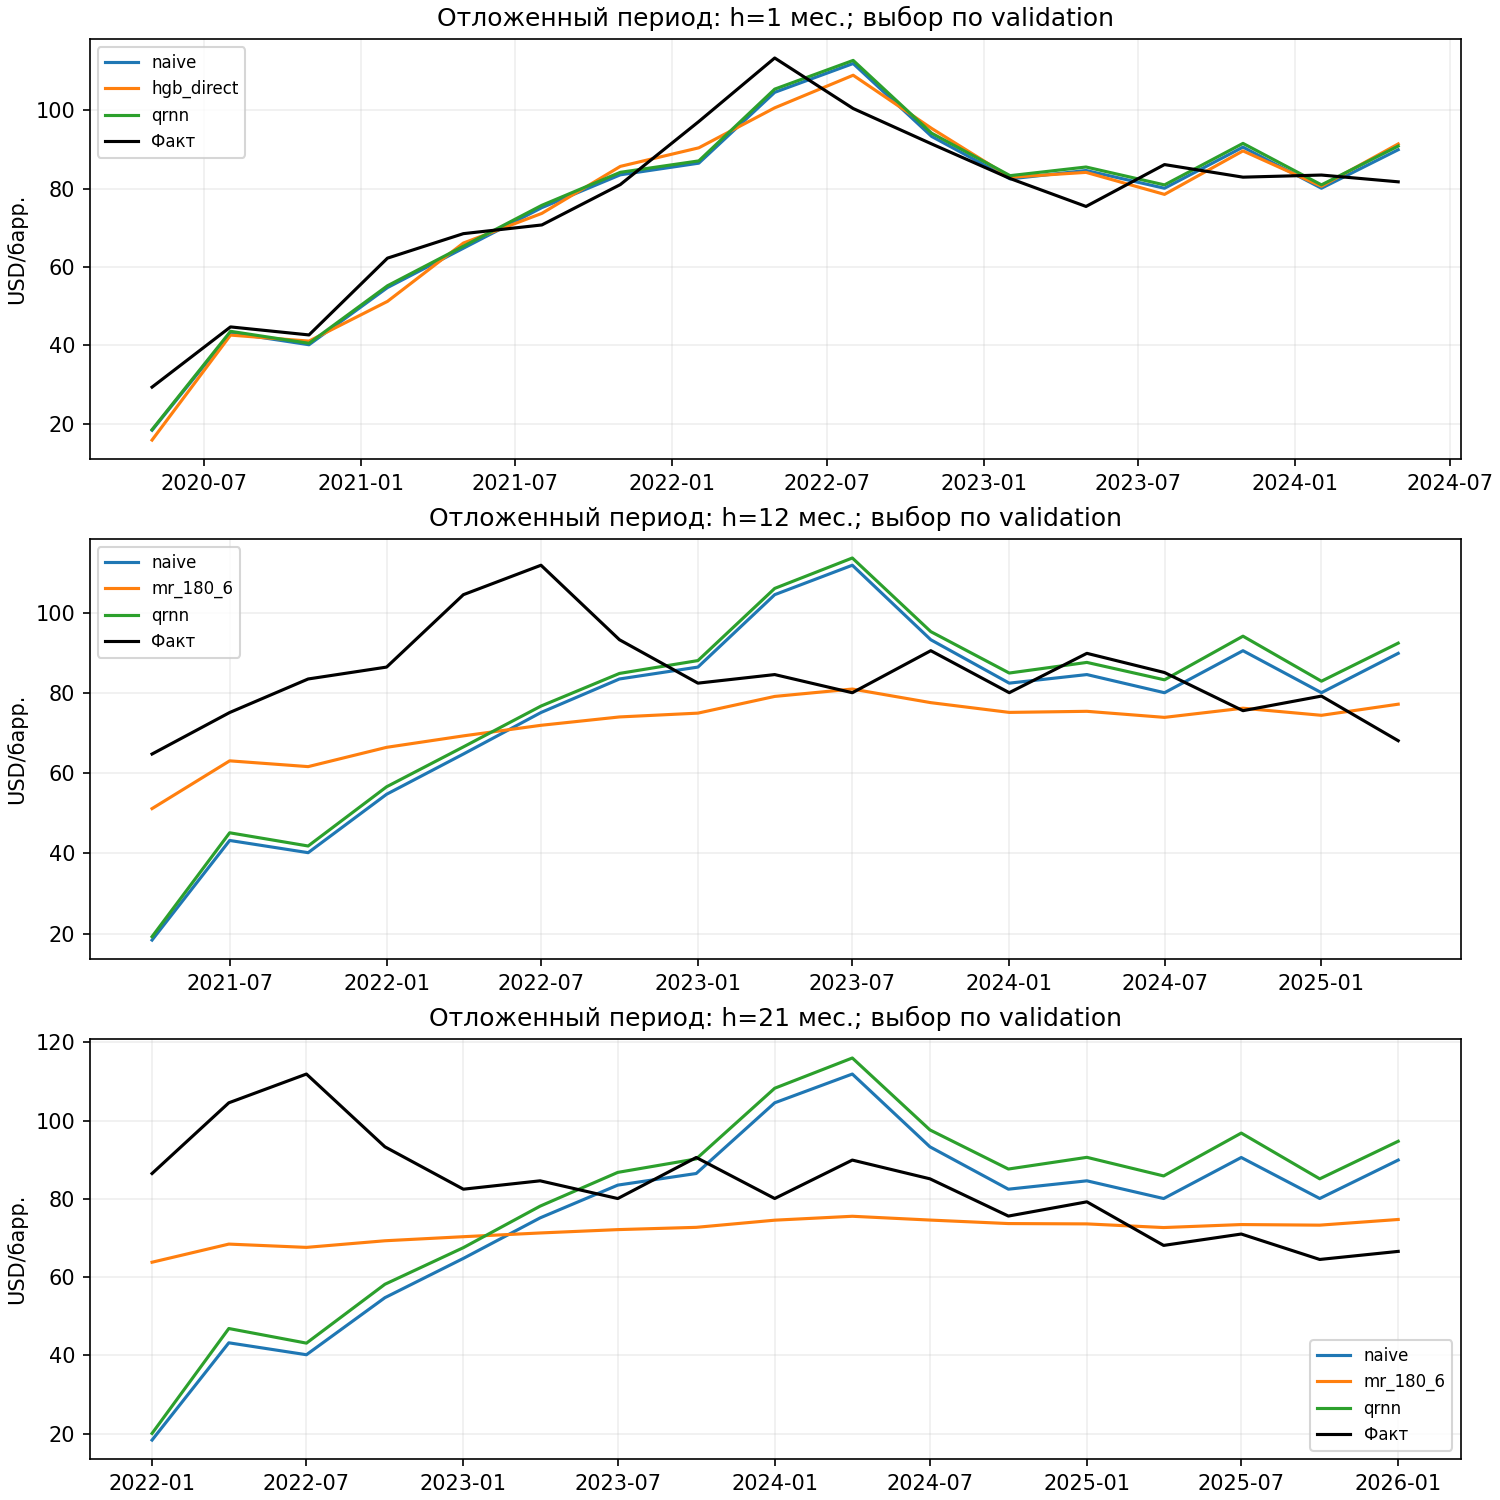

In [4]:
display(Markdown((E / "RESULTS.md").read_text()))
display(Image(filename=str(E / "test_forecasts.png")))


## Чувствительность и состав ансамбля

MR: окно 60/120/180 месяцев и half-life 6/12/24 сравниваются на validation.
Для ансамбля показано исключение каждого участника; Ridge не сохраняется автоматически
ради количества моделей. Таблица ниже — средняя MAE по 21 горизонту как обзор,
а фактический выбор выполнялся отдельно для каждого горизонта.

In [5]:
v = metrics[metrics.period=="validation"]
for prefix in ["mr_","ensemble"]:
    display(v[v.model.str.startswith(prefix)].groupby("model")[["MAE","RMSE","relative_MAE"]].mean().round(3))


,MAE,RMSE,relative_MAE
model,,,
mr_120_12,13.597,18.108,0.893
mr_120_24,13.371,18.441,0.882
mr_120_6,15.937,19.554,1.032
mr_180_12,10.104,13.035,0.684
mr_180_24,12.024,15.759,0.800
mr_180_6,8.679,10.855,0.597
mr_60_12,16.061,22.006,1.045
mr_60_24,14.637,20.640,0.959
mr_60_6,19.670,25.417,1.271


,MAE,RMSE,relative_MAE
model,,,
ensemble_all,15.451,21.317,1.020
ensemble_without_ets_log,15.918,21.776,1.056
ensemble_without_mr_120_12,17.257,23.261,1.134
ensemble_without_naive,15.556,21.550,1.034
ensemble_without_ridge_direct,13.734,19.179,0.901


## QRNN: калибровка и устойчивость

Сеть не обязана выигрывать. Покрытие сравнивается с 90%, ширина — вместе с покрытием.
`crps_central_approx` интегрирует pinball только по сетке 0.05–0.95, без хвостов;
это не полный CRPS. Столбцы pinball, width и interval score в USD/баррель.
Метрики рассчитываются после обратного преобразования в цены.
Отдельный seed не выбирался по test: основной прогноз усредняет все пять.

In [6]:
q = metrics[(metrics.period=="test")&metrics.model.isin(["qrnn","naive_quantiles"])&metrics.horizon.isin(key_horizons)]
display(q[["model","horizon","n","MAE","pinball","crps_central_approx","coverage90","width90","interval_score90"]].round(3))
seeds = pd.read_csv(E / "seed_metrics.csv")
display(seeds[(seeds.period=="test")&(seeds.model=="qrnn")&(seeds.horizon==21)][["seed","MAE","coverage90","width90"]].round(3))
audit = json.loads((E / "training_audit.json").read_text())
cross = [r["crossing_fraction_raw"] for r in audit if r["model"]=="qrnn" and r["period"]=="test"]
display(Markdown(f"До коррекции пересечения встречались в среднем в **{sum(cross)/len(cross):.1%}** пар seed × горизонт; после изотонической коррекции порядок квантилей соблюдён."))


,model,horizon,n,MAE,pinball,crps_central_approx,coverage90,width90,interval_score90
567,naive_quantiles,1,17,6.011,2.141,3.990,0.882,20.940,31.481
569,naive_quantiles,3,17,9.742,3.654,6.770,0.882,43.208,69.310
572,naive_quantiles,6,17,13.960,5.220,9.707,0.882,60.851,84.234
578,naive_quantiles,12,17,21.158,8.557,15.885,0.824,90.384,149.623
587,naive_quantiles,21,17,28.004,11.042,20.385,0.824,115.613,237.490
588,qrnn,1,17,5.983,2.274,4.211,0.529,11.263,43.488
590,qrnn,3,17,9.834,3.730,6.909,0.647,21.954,70.815
593,qrnn,6,17,13.792,5.374,9.955,0.588,32.640,102.625
599,qrnn,12,17,20.581,8.648,15.965,0.588,50.962,186.094
608,qrnn,21,17,25.821,10.579,19.495,0.765,62.896,241.991


,seed,MAE,coverage90,width90
62,11,25.379,0.765,57.196
230,23,26.059,0.765,64.998
398,37,26.126,0.765,64.309
524,53,25.454,0.765,61.341
566,71,26.110,0.765,66.635


До коррекции пересечения встречались в среднем в **32.4%** пар seed × горизонт; после изотонической коррекции порядок квантилей соблюдён.

## Прогноз до конца 2027 года

Точечная линия выбрана по validation. Квантильный веер относится **отдельно к QRNN**;
его нельзя называть интервалом выбранной MR-модели. Данные после марта 2026
не добавлялись. Полный CSV с 19 квантилями лежит рядом с графиком.

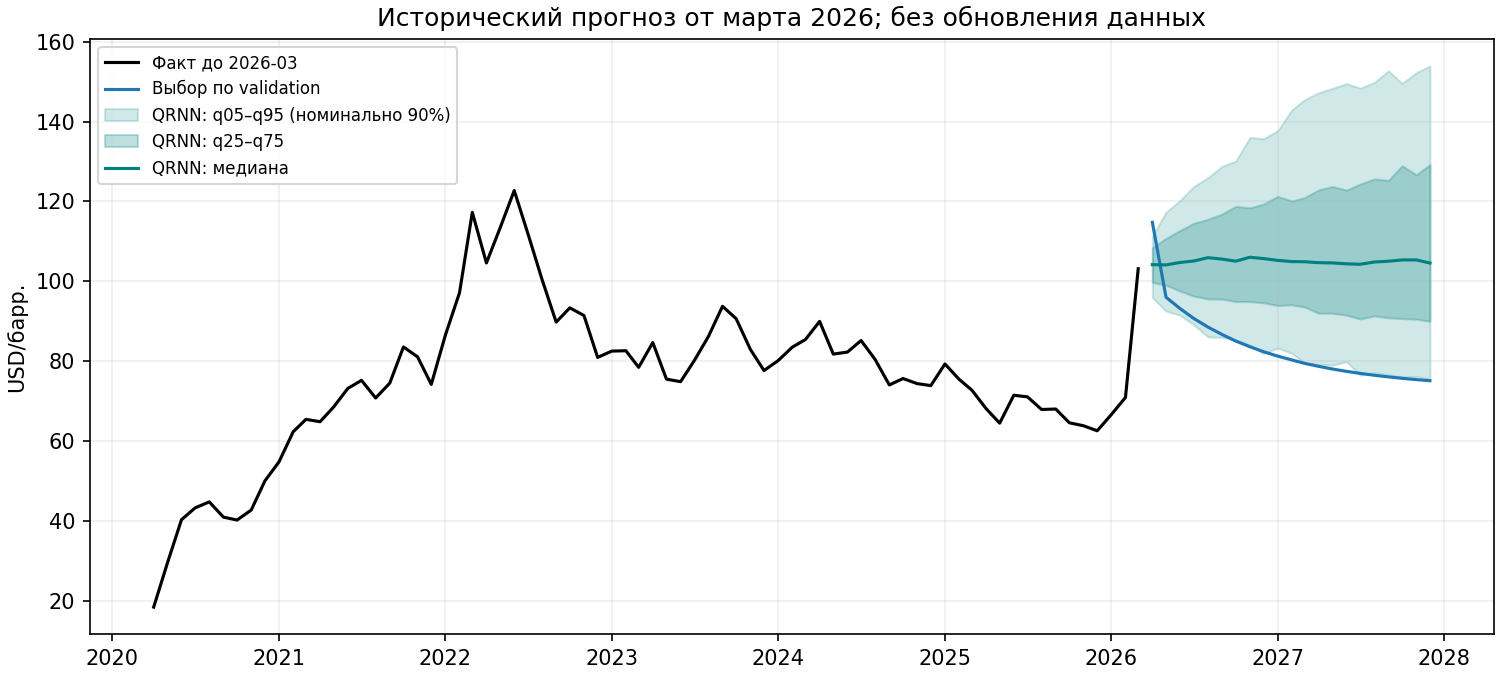

,date,horizon,model,forecast
0,2026-04-01,1,hgb_direct,114.74
1,2026-05-01,2,mr_180_6,95.98
2,2026-06-01,3,mr_180_6,93.13
3,2026-07-01,4,mr_180_6,90.66
4,2026-08-01,5,mr_180_6,88.52
5,2026-09-01,6,mr_180_6,86.65
6,2026-10-01,7,mr_180_6,85.02
7,2026-11-01,8,mr_180_6,83.59
8,2026-12-01,9,mr_180_6,82.34
9,2027-01-01,10,mr_180_6,81.24


In [7]:
display(Image(filename=str(E / "quantile_forecast.png")))
display(pd.read_csv(E / "selected_forecast.csv").round(2))


**Вывод по Brent.** На h=1 validation выбрала HGB, который в test проиграл naive.
Для h=2–21 выбрана MR(180,6). На h=21 её MAE test — 14.13 против 24.22 USD/барр.
у naive. К декабрю 2027 она даёт около 75.08 USD/барр. от мартовского среза.
QRNN не победила и недопокрывает интервал; на h=21 фактическое покрытие 76.5%.
Выбор из многих моделей на короткой validation может быть нестабилен.

Команды быстрого/полного запуска: `task1_brent/EXTENDED_METHOD.md`.
Старое сравнение семи методов сохранено в `task1_brent/outputs/` вне `extended_full`.


# **Задание 2**

Необходимо разработать чат-бота в телеграмме в формате системы вопрос-ответ с использованием генеративного подхода. Бот должен имитировать общение отраслевого эксперта в области электроэнергетики. 

Реализация должна быть основана на API DeepSeek (в начале диалога необходимо запросить у пользователя ключ API, затем бот начинает работу с приветствия пользователя). В качестве дополнительной базы знаний необходимо интегрировать технологию RAG, которая обеспечит обращение бота к данным в документах, доступных по следующим ссылкам:
 - https://www.so-ups.ru/fileadmin/files/company/future_plan/public_discussion/2025-30_final/sipr_ups_2025-30_fin.pdf
 - https://www.iea.org/reports/electricity-2025
 - https://www.iea.org/reports/global-energy-review-2025

## Бот: путь вопроса к ответу

PDF → постраничные фрагменты → BM25/E5 → опциональный reranker → ответ модели →
проверка цитат → опциональная проверка смысла и соответствия вопросу → Telegram.

Приветствие и ошибки переписаны на спокойное «ты». API-сбой отличается от недостатка
подтверждения. Стиль меняется в исходном промпте, без отдельного платного запроса.
Пользовательские ключи разделены по сессиям и не выводятся в логи.

Ниже прежняя **dev-оценка поиска**, не новая проверка реальных ответов.

In [8]:
retrieval = pd.read_csv(ROOT / "task2_bot/outputs/dev_ablation/summary.csv")
display(retrieval.round(3))


,configuration,n,page_hits,all_sources_hit,all_evidence_pages_hit,mrr
0,bm25_translation-0_scope-1_weight-0.25,17,5,16,5,0.123
1,bm25_translation-0_scope-0_weight-0.25,17,2,10,2,0.078
2,bm25_translation-1_scope-1_weight-0.25,17,13,17,10,0.505
3,bm25_translation-1_scope-0_weight-0.25,17,11,16,9,0.375
4,semantic_translation-0_scope-1_weight-0.25,17,10,16,9,0.230
5,semantic_translation-0_scope-0_weight-0.25,17,7,15,6,0.139
6,semantic_translation-1_scope-1_weight-0.25,17,12,17,10,0.404
7,semantic_translation-1_scope-0_weight-0.25,17,11,17,9,0.355
8,hybrid_translation-0_scope-1_weight-0.25,17,8,16,8,0.198
9,hybrid_translation-0_scope-0_weight-0.25,17,5,15,5,0.139


**Вывод по боту.** Основной сценарий и переключатели покрыты офлайн-тестами,
включая нормальный вопрос, уточнение, неверную предпосылку, отказ и API-ошибку.
Эти примеры используют моки. Живой DeepSeek и реальный reranker в этой доработке
не вызывались. Прежние 14/17 на dev с ручным переводом не выдаются за test-качество.

Запуск и переключатели: `task2_bot/README.md`. Для живой проверки нужны твои ключи.


# **Задание 3**

Необходимо реализовать алгоритм автоматической выгрузки данных с сайта https://br.so-ups.ru/ 

*(пропустить уведомление о небезопасности перехода к сайту)*

Результатом будет файл Excel с фактическими почасовыми данными каждого дня предыдущего месяца по каждой энергосистеме (С-Запад, Центр, Юг, Ср. Волга, Урал, Сибирь, Восток) на 3 листах:
- Генерация (МВт*ч)
- Потребление (МВт*ч)
- Среднее ИБР (руб./МВт*ч)

## Excel: что получается на выходе

Один итоговый файл: `task3_excel/outputs/electricity_2026-09.xlsx`.
Сохранённые 31 ответ API повторно дали 5040 идентичных строк. Генерация и потребление
полные. 720 цен Востока в API отсутствуют; общий ИБР семи ОЭС оставлен пустым.
Рядом показаны **частичные** средние, число опубликованных цен и покрытие веса.
Вес по потреблению — аналитическое допущение.

ОЭС Востока включена во вторую ценовую зону с 01.01.2025 согласно СО ЕЭС;
поле `unPriceTerritories` не доказывает неприменимость ИБР в 2026 году.
Причина null в этом API остаётся неизвестной. Источники: `docs/SITE_RECON.md`.

Суммы и средние — формулы Excel. Фильтр исключает месячные итоги.


In [9]:
book = load_workbook(ROOT / "task3_excel/outputs/electricity_2026-09.xlsx", data_only=True)
for sheet in book:
    display(Markdown(f"**{sheet.title}** — {sheet['A2'].value}"))
    headers = [cell.value for cell in sheet[4]]
    display(pd.DataFrame(list(sheet.iter_rows(min_row=5,max_row=7,values_only=True)),columns=headers))
    display(pd.DataFrame([tuple(cell.value for cell in sheet[sheet.max_row])],columns=headers))


**Генерация (МВт·ч)** — ДАННЫЕ ПОЛНЫЕ. 01.09.2026 — 30.09.2026. Europe/Moscow. Факт.

,Дата,Час начала,С-Запад,Центр,Юг,Ср. Волга,Урал,Сибирь,Восток,ВСЕГО
0,2026-09-01,0,10734,22221,10797,10654,21942,21448,4722,102518
1,2026-09-01,1,10463,21853,10986,10429,20893,21713,5024,101361
2,2026-09-01,2,10390,21710,10965,10641,20639,22048,5096,101489


,Дата,Час начала,С-Запад,Центр,Юг,Ср. Волга,Урал,Сибирь,Восток,ВСЕГО
0,Итого за месяц,None,8221085,18375091,8822411,8531864,19147818,17322306,3586726,84007301


**Потребление (МВт·ч)** — ДАННЫЕ ПОЛНЫЕ. 01.09.2026 — 30.09.2026. Europe/Moscow. Факт.

,Дата,Час начала,С-Запад,Центр,Юг,Ср. Волга,Урал,Сибирь,Восток,ВСЕГО
0,2026-09-01,0,9071,23640,9772,10540,23493,21504,4729,102749
1,2026-09-01,1,8752,22943,9392,10428,23352,21737,5022,101626
2,2026-09-01,2,8581,22561,9181,10517,23414,22574,5078,101906


,Дата,Час начала,С-Запад,Центр,Юг,Ср. Волга,Урал,Сибирь,Восток,ВСЕГО
0,Итого за месяц,None,7428947,19750492,8193576,8658309,18432656,17333667,3575893,83373540


**Среднее ИБР (руб. за МВт·ч)** — НЕПОЛНЫЕ ДАННЫЕ ИБР: 720 цен не опубликованы источником. Интервалы загружены. 01.09.2026 — 30.09.2026. Europe/Moscow. Факт.

,Дата,Час начала,С-Запад,Центр,Юг,Ср. Волга,Урал,Сибирь,Восток,Все 7 ОЭС,По опубликованным: взвешенное,По опубликованным: простое,"Цен, шт.",Покрытие веса
0,2026-09-01,0,895.945800,929.52880,224.706375,1030.49536,1523.94934,832.1989,None,None,988.126749,906.137429,6,0.953975
1,2026-09-01,1,545.289551,494.10376,117.841600,678.23820,1184.53625,594.1438,None,None,671.444529,602.358860,6,0.950584
2,2026-09-01,2,237.205551,427.45420,320.920500,843.05950,1168.00400,591.9454,None,None,663.055150,598.098192,6,0.950170


,Дата,Час начала,С-Запад,Центр,Юг,Ср. Волга,Урал,Сибирь,Восток,Все 7 ОЭС,По опубликованным: взвешенное,По опубликованным: простое,"Цен, шт.",Покрытие веса
0,Среднее за месяц,None,1857.071361,2480.71377,2337.1343,2403.447677,2042.793861,1282.417684,None,None,2038.077639,2028.958625,4320,0.95711


**Вывод по Excel.** Суммарная генерация — 84 007 301 МВт·ч, потребление —
83 373 540 МВт·ч. Частичный взвешенный ИБР — 2038.08 руб./МВт·ч,
4320 опубликованных пар, покрытие веса 95.71%. Это не полный итог всех семи ОЭС.

В `task3_excel/README.md` есть полные команды и таблица «команда → вход → выход».
Офлайн-проверка не требует API-ключа. Код 3 означает, что книга создана с неполными
ценами; код 2 — ошибку. Готовый файл на Mac открывается командой:

```bash
open task3_excel/outputs/electricity_2026-09.xlsx
```

## Проверки и ограничения

Полный CPU-эксперимент, офлайн-тесты и воспроизведение Excel выполнены.
Подробности — `docs/CURRENT_VALIDATION.md`. Отдельно остаются живой Telegram/DeepSeek,
качество реального reranker, запуск на Mac и визуальная сверка графика сайта.
Исходный мартовский срез Brent и все фактические значения Excel сохранены.
